# FM fit — fixed R=1 loop (perimeter-4 plaquette)

Self-contained analysis of the **size-independent** FM order parameter: a fixed
`R=1` σ^z plaquette (closed = 4 edges, open = 2), the *same physical operator at
every L*, so all L-dependence is genuine correlation-length physics rather than
the growing-loop (`R=L−3`) operator changing shape with L.

Consumes `fm_L*_hx0.0_bulkR1.json` (extracted with `R=1`, `eval_chains=16`).
Contents: **1** config · **2** load · **3** data + derivative dictionaries ·
**4** derivative plots · **5** per-L transition fit · **6** FSS → h_c(∞).


In [1]:
%matplotlib inline
import glob, json, os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import erf


## 1 · CONFIG — the one cell to edit

In [3]:
# ---- data ------------------------------------------------------------------
DATA_DIR = "/Users/sanzhar123/Desktop/Approximate-Symmetries-TC-main/results/phase_hx0.0_bulkR1"
OBS      = "O"          # "O" = O_FM   |   "mz" = <sigma_z>

# ---- point selection -------------------------------------------------------
EXCLUDE   = {}          # {L: [hz, ...]} bad/collapsed points to drop
HZ_WINDOW = None        # None, or (lo, hi) hz window applied to every L

# ---- per-L transition fit --------------------------------------------------
PERL_FORM = "logistic"  # "logistic" | "tanh" | "erf"  (h_c = inflection)
WEIGHTED  = True        # use O_FM errorbars as curve_fit sigma

# ---- finite-size scaling of h_c(L):  h_c(L) = h_c(inf) + b*(1/L)**x ---------
FSS_FIX_X = None        # None -> x free (bounded >=0.1); or a float to PIN x (e.g. 2.0)
FSS_LS    = None        # e.g. [5,6,7] subset of L for the FSS (None = all)
HC_BY_L   = None        # None -> use the per-L logistic h_c; or {L: value} to override

# ---- reference -------------------------------------------------------------
HZ_C_TRUE = 0.197       # QMC h_c at hx=0 (thermodynamic limit)


## 2 · Load + point selection

In [4]:
def load_curves(directory):
    recs = [json.load(open(jp))
            for jp in sorted(glob.glob(os.path.join(directory, "fm_L*.json")))]
    if not recs:
        raise SystemExit(f"no fm_L*.json in {directory} -- pull the extracted curves first")
    return sorted(recs, key=lambda r: r["L"])

def get_arrays(rec, obs=None, exclude=None, window=None):
    """(hz, y, ye) for one L after applying EXCLUDE + HZ_WINDOW."""
    obs = OBS if obs is None else obs
    exclude = EXCLUDE if exclude is None else exclude
    window = HZ_WINDOW if window is None else window
    hz = np.array(rec["field"], float)
    y  = np.array(rec[obs], float)
    ye = np.array(rec.get("Oe" if obs == "O" else "mz_e", np.zeros_like(y)), float)
    keep = np.ones(len(hz), bool)
    for h in exclude.get(rec["L"], []):
        keep &= ~np.isclose(hz, h, atol=1e-6)
    if window is not None:
        keep &= (hz >= window[0]) & (hz <= window[1])
    return hz[keep], y[keep], ye[keep]

recs = load_curves(DATA_DIR)
_r0 = recs[0]
print(f"loaded L = {[r['L'] for r in recs]}   placement = {_r0.get('placement','?')}"
      f"   R = {_r0.get('R','?')}   hx = {_r0.get('hx','?')}   obs = {OBS}")
for r in recs:
    hz, y, ye = get_arrays(r)
    nan_e = int(np.sum(~np.isfinite(ye)) + np.sum(ye == 0))
    print(f"  L={r['L']}: {len(hz):2d} pts kept (dropped {len(r['field'])-len(hz)})"
          f"   hz in [{hz.min():.3g}, {hz.max():.3g}]   R={r.get('R')}"
          + (f"   [warn {nan_e} nan/zero errbars]" if nan_e else ""))


loaded L = [4, 5, 6, 7]   placement = bulk   R = 1   hx = 0.0   obs = O
  L=4: 13 pts kept (dropped 0)   hz in [0.1, 0.4]   R=1
  L=5: 13 pts kept (dropped 0)   hz in [0.1, 0.4]   R=1
  L=6: 13 pts kept (dropped 0)   hz in [0.1, 0.4]   R=1
  L=7: 13 pts kept (dropped 0)   hz in [0.1, 0.4]   R=1


## 3 · Data + derivative dictionaries

`data_rows` = one dict per (L, hz): `O`, `Oe`. `deriv_rows` = same grid with
`dO` = dO_FM/dhz (np.gradient = central difference on the hz grid). Query freely, e.g.

```python
[d for d in data_rows if d["L"] == 6]
max((d for d in deriv_rows if d["L"] == 7), key=lambda d: abs(d["dO"]))
```


In [5]:
data_rows, deriv_rows = [], []
for r in recs:
    hz, O, Oe = get_arrays(r)                     # respects OBS/EXCLUDE/HZ_WINDOW
    dO = np.gradient(O, hz)                        # dO_FM/dhz at each hz (central diff)
    for k in range(len(hz)):
        data_rows.append({"L": r["L"], "hz": round(float(hz[k]), 4),
                          "O": float(O[k]), "Oe": float(Oe[k])})
        deriv_rows.append({"L": r["L"], "hz": round(float(hz[k]), 4), "dO": float(dO[k])})

for r in recs:
    L = r["L"]
    print(f"\nL={L}:")
    ders = {d["hz"]: d["dO"] for d in deriv_rows if d["L"] == L}
    for d in (x for x in data_rows if x["L"] == L):
        print(f"   hz={d['hz']:<6} O={d['O']:+.4f}  Oe={d['Oe']:.4f}  dO/dhz={ders[d['hz']]:+.3f}")
    pk = max((d for d in deriv_rows if d["L"] == L), key=lambda d: abs(d["dO"]))
    print(f"   -> steepest at hz={pk['hz']} (|dO/dhz|={abs(pk['dO']):.3f})  <- candidate h_c(L)")



L=4:
   hz=0.1    O=+0.0145  Oe=0.0099  dO/dhz=+0.195
   hz=0.125  O=+0.0194  Oe=0.0099  dO/dhz=-0.008
   hz=0.15   O=+0.0141  Oe=0.0100  dO/dhz=+0.236
   hz=0.175  O=+0.0312  Oe=0.0103  dO/dhz=+0.659
   hz=0.2    O=+0.0470  Oe=0.0104  dO/dhz=+0.710
   hz=0.225  O=+0.0667  Oe=0.0109  dO/dhz=+0.986
   hz=0.25   O=+0.0964  Oe=0.0112  dO/dhz=+1.777
   hz=0.275  O=+0.1555  Oe=0.0122  dO/dhz=+3.216
   hz=0.3    O=+0.2572  Oe=0.0126  dO/dhz=+6.074
   hz=0.325  O=+0.4592  Oe=0.0132  dO/dhz=+8.438
   hz=0.35   O=+0.6790  Oe=0.0113  dO/dhz=+5.822
   hz=0.375  O=+0.7503  Oe=0.0101  dO/dhz=+2.515
   hz=0.4    O=+0.8048  Oe=0.0091  dO/dhz=+2.178
   -> steepest at hz=0.325 (|dO/dhz|=8.438)  <- candidate h_c(L)

L=5:
   hz=0.1    O=-0.0161  Oe=0.0134  dO/dhz=+2.178
   hz=0.125  O=+0.0383  Oe=0.0135  dO/dhz=+1.291
   hz=0.15   O=+0.0484  Oe=0.0137  dO/dhz=-0.207
   hz=0.175  O=+0.0280  Oe=0.0139  dO/dhz=-0.024
   hz=0.2    O=+0.0472  Oe=0.0144  dO/dhz=+0.700
   hz=0.225  O=+0.0630  Oe=0.0147  dO/dhz

## 4 · Derivative of O_FM per L (peak = candidate transition)

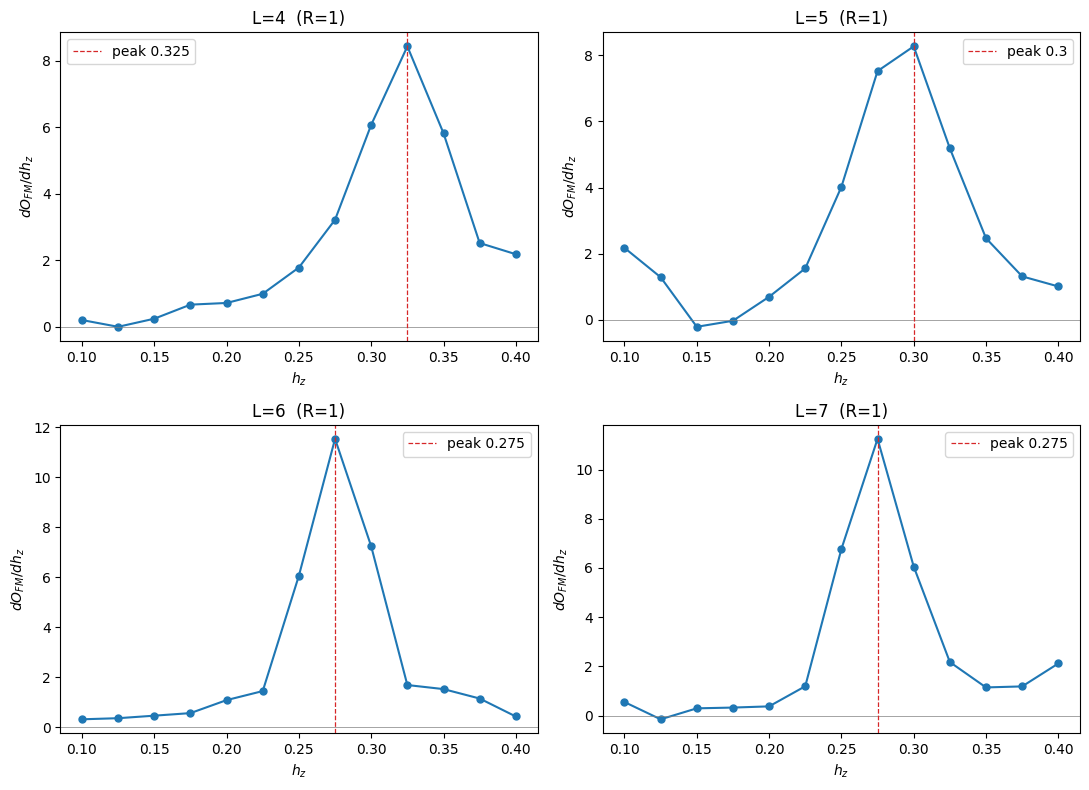

In [6]:
Ls = [r["L"] for r in recs]
ncol = 2; nrow = int(np.ceil(len(Ls) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(11, 4 * nrow), squeeze=False)
for L, ax in zip(Ls, axes.flat):
    dL = sorted((d for d in deriv_rows if d["L"] == L), key=lambda d: d["hz"])
    hz = [d["hz"] for d in dL]; dO = [d["dO"] for d in dL]
    ax.plot(hz, dO, "-o", ms=5)
    ax.axhline(0, color="gray", lw=0.5)
    pk = max(dL, key=lambda d: abs(d["dO"]))
    ax.axvline(pk["hz"], ls="--", color="C3", lw=0.9, label=f"peak {pk['hz']}")
    ax.set(xlabel="$h_z$", ylabel="$dO_{FM}/dh_z$", title=f"L={L}  (R=1)")
    ax.legend()
for ax in axes.flat[len(Ls):]:
    ax.axis("off")
fig.tight_layout(); plt.show()


## 5 · Per-L transition fit  (sigmoid inflection = h_c(L))

  L  npts      h_c  h_c_err   hc_fd   width
  4    13   0.3202   0.0016   0.338  0.0257
  5    13   0.2925   0.0014   0.287  0.0222
  6    13   0.2768   0.0012   0.287  0.0155
  7    13   0.2768   0.0014   0.263  0.0149


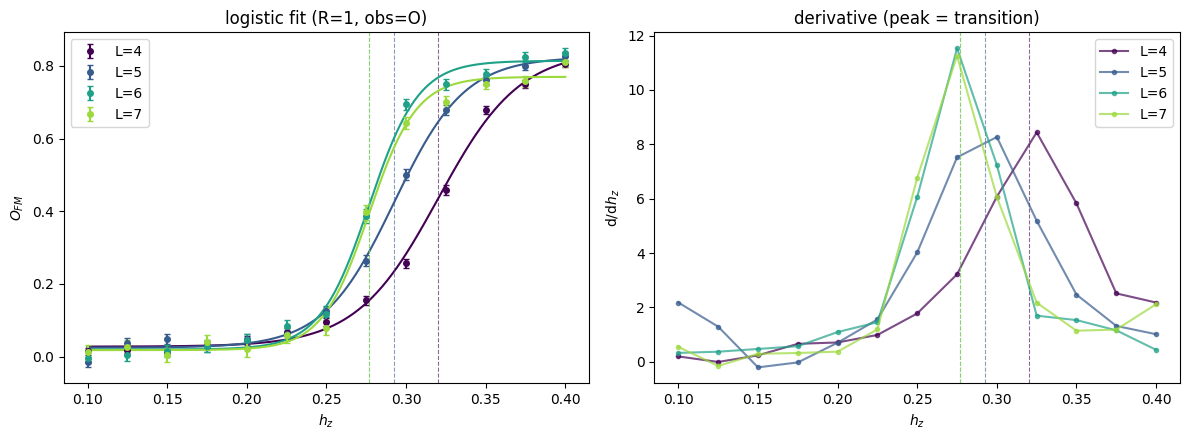

In [7]:
def _logistic(h, a, b, h0, w): return a + b / (1.0 + np.exp(-(h - h0) / w))
def _tanh(h, a, b, h0, w):     return a + b * np.tanh((h - h0) / w)
def _erf(h, a, b, h0, w):      return a + b * erf((h - h0) / w)
PERL = {"logistic": _logistic, "tanh": _tanh, "erf": _erf}

def _p0(form, hz, y):
    rng = (hz[-1] - hz[0]) or 1.0
    if form == "logistic":
        return [y[0], y[-1] - y[0], float(np.median(hz)), 0.1 * rng]
    return [0.5 * (y[0] + y[-1]), 0.5 * (y[-1] - y[0]), float(np.median(hz)), 0.1 * rng]

def fit_transition(hz, y, ye, form=None, weighted=None):
    """Fit the chosen sigmoid; return h_c (= inflection h0), its error, curve, width,
    and a model-free finite-difference derivative-peak cross-check."""
    form = PERL_FORM if form is None else form
    weighted = WEIGHTED if weighted is None else weighted
    f = PERL[form]
    kw = dict(sigma=ye, absolute_sigma=True) if (weighted and np.all(ye > 0)) else {}
    popt, pcov = curve_fit(f, hz, y, p0=_p0(form, hz, y), maxfev=40000, **kw)
    hh = np.linspace(hz.min(), hz.max(), 400)
    hm = 0.5 * (hz[1:] + hz[:-1]); d = np.diff(y) / np.diff(hz)
    hc_fd = float(hm[int(np.argmax(np.abs(d)))]) if len(hm) else float("nan")
    return dict(popt=popt, h_c=float(popt[2]), h_c_err=float(np.sqrt(abs(pcov[2, 2]))),
                width=abs(float(popt[3])), hc_fd=hc_fd, curve=(hh, f(hh, *popt)))

fits = {}
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
colors = plt.cm.viridis(np.linspace(0, 0.85, len(recs)))
ylab = r"$O_{FM}$" if OBS == "O" else r"$\langle\sigma_z\rangle$"
print(f"{'L':>3} {'npts':>5} {'h_c':>8} {'h_c_err':>8} {'hc_fd':>7} {'width':>7}")
for rec, c in zip(recs, colors):
    L = rec["L"]; hz, y, ye = get_arrays(rec)
    fit = fit_transition(hz, y, ye); fits[L] = fit
    ax[0].errorbar(hz, y, yerr=ye, fmt="o", ms=4, capsize=2, color=c, label=f"L={L}")
    hh, yy = fit["curve"]; ax[0].plot(hh, yy, "-", color=c)
    ax[0].axvline(fit["h_c"], ls="--", color=c, lw=0.8, alpha=0.6)
    ax[1].plot(hz, np.gradient(y, hz), "o-", ms=3, color=c, alpha=0.7, label=f"L={L}")
    ax[1].axvline(fit["h_c"], ls="--", color=c, lw=0.8, alpha=0.6)
    print(f"{L:>3} {len(hz):>5} {fit['h_c']:>8.4f} {fit['h_c_err']:>8.4f} "
          f"{fit['hc_fd']:>7.3f} {fit['width']:>7.4f}")
ax[0].set(xlabel="$h_z$", ylabel=ylab, title=f"{PERL_FORM} fit (R=1, obs={OBS})"); ax[0].legend()
ax[1].set(xlabel="$h_z$", ylabel="d/d$h_z$", title="derivative (peak = transition)"); ax[1].legend()
plt.tight_layout(); plt.show()


## 6 · Finite-size scaling  →  h_c(∞)

Fit `h_c(L) = h_c(∞) + b·(1/L)^x`. By default `h_c(L)` is the per-L logistic
inflection from §5 (set `HC_BY_L` in the config to override by hand). `x` is free
(bounded ≥0.1) unless `FSS_FIX_X` pins it — pin `FSS_FIX_X = 2.0` for the
(3+1)D-Ising / mean-field `x = 1/ν = 2` expectation.


h_c(L):  L4=0.3202  L5=0.2925  L6=0.2768  L7=0.2768
fit:  h_c(L) = 0.2689 + (11.1613)*(1/L)**3.8772   [x free = 3.877+-0.645,  weights ON]
  ==>  h_c(inf) = 0.2689 +- 0.0034    (QMC true = 0.197;  offset = +0.0719)


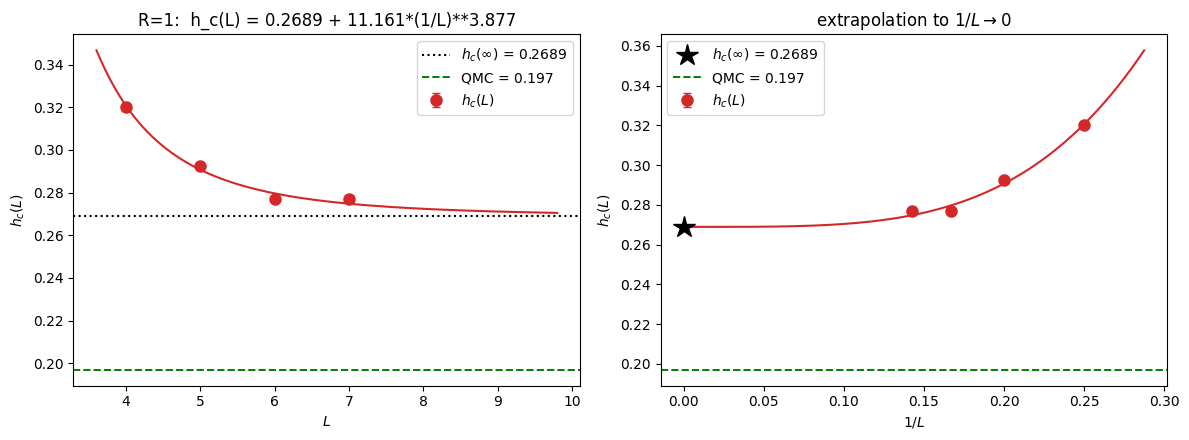

In [8]:
def hc_model(L, hc_inf, b, x):
    return hc_inf + b * (1.0 / np.asarray(L, float)) ** x

# h_c(L): manual override if given, else the per-L logistic inflection (with errors)
if HC_BY_L is not None:
    hc_by_L = {int(k): float(v) for k, v in HC_BY_L.items()}
    err_by_L = {int(k): np.nan for k in hc_by_L}
else:
    hc_by_L = {L: fits[L]["h_c"] for L in fits}
    err_by_L = {L: fits[L]["h_c_err"] for L in fits}

use_L = sorted(hc_by_L) if FSS_LS is None else sorted(int(x) for x in FSS_LS)
Lm  = np.array(use_L, float)
hcm = np.array([hc_by_L[int(k)] for k in use_L])
hce = np.array([err_by_L[int(k)] for k in use_L])
w_ok = np.all(np.isfinite(hce)) and np.all(hce > 0)
fkw = dict(sigma=hce, absolute_sigma=True) if w_ok else {}

if FSS_FIX_X is None:                       # x free (bounded away from 0 for identifiability)
    popt, pcov = curve_fit(hc_model, Lm, hcm, p0=[hcm.min(), 0.3, 1.5],
                           bounds=([-np.inf, -np.inf, 0.1], [np.inf, np.inf, 6.0]),
                           maxfev=40000, **fkw)
    hc_inf, b, x = map(float, popt); x_err = float(np.sqrt(abs(pcov[2, 2])))
else:                                       # x pinned -> 2-param fit
    g = lambda L, hc_inf, b: hc_model(L, hc_inf, b, FSS_FIX_X)
    popt, pcov = curve_fit(g, Lm, hcm, p0=[hcm.min(), 0.3], maxfev=40000, **fkw)
    hc_inf, b, x, x_err = float(popt[0]), float(popt[1]), float(FSS_FIX_X), 0.0
hc_inf_err = float(np.sqrt(abs(pcov[0, 0])))

fss = dict(hc_inf=hc_inf, hc_inf_err=hc_inf_err, b=b, x=x, x_err=x_err, L=Lm, hc=hcm, hce=hce)
print("h_c(L):  " + "  ".join(f"L{int(k)}={v:.4f}" for k, v in zip(use_L, hcm)))
print(f"fit:  h_c(L) = {hc_inf:.4f} + ({b:.4f})*(1/L)**{x:.4f}"
      f"   [x {'FIXED' if FSS_FIX_X is not None else f'free = {x:.3f}+-{x_err:.3f}'}"
      f",  weights {'ON' if w_ok else 'off'}]")
print(f"  ==>  h_c(inf) = {hc_inf:.4f} +- {hc_inf_err:.4f}"
      f"    (QMC true = {HZ_C_TRUE};  offset = {hc_inf - HZ_C_TRUE:+.4f})")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
LL = np.linspace(Lm.min() * 0.9, Lm.max() * 1.4, 200)
ax[0].errorbar(Lm, hcm, yerr=(hce if w_ok else None), fmt="o", ms=8, color="C3", capsize=3,
               label="$h_c(L)$")
ax[0].plot(LL, hc_model(LL, hc_inf, b, x), "-", color="C3")
ax[0].axhline(hc_inf, ls=":", color="k", label=rf"$h_c(\infty)$ = {hc_inf:.4f}")
ax[0].axhline(HZ_C_TRUE, ls="--", color="green", lw=1.4, label=f"QMC = {HZ_C_TRUE}")
ax[0].set(xlabel="$L$", ylabel="$h_c(L)$",
          title=f"R=1:  h_c(L) = {hc_inf:.4f} + {b:.3f}*(1/L)**{x:.3f}"); ax[0].legend()
invL = 1.0 / Lm; grid = np.linspace(0, invL.max() * 1.15, 200)
ax[1].errorbar(invL, hcm, yerr=(hce if w_ok else None), fmt="o", ms=8, color="C3", capsize=3,
               label="$h_c(L)$")
ax[1].plot(grid, hc_inf + b * grid ** x, "-", color="C3")
ax[1].plot(0, hc_inf, "*", ms=16, color="k", label=rf"$h_c(\infty)$ = {hc_inf:.4f}")
ax[1].axhline(HZ_C_TRUE, ls="--", color="green", lw=1.4, label=f"QMC = {HZ_C_TRUE}")
ax[1].set(xlabel="$1/L$", ylabel="$h_c(L)$", title=r"extrapolation to $1/L\to0$"); ax[1].legend()
plt.tight_layout(); plt.show()


## 7 · Manual FSS — you supply h_c(L)

Type the pseudo-critical field for each L into `HC_MANUAL` (pre-filled from the §5
logistic fits — overwrite by eyeballing the §4 derivative peaks), then fit
`h_c(L) = h_c(∞) + b·(1/L)^x`. Set `X_FIXED = None` to let x float (bounded ≥0.1),
or pin it (e.g. `2.0` for the (3+1)D-Ising / mean-field `x = 1/ν`). Unweighted —
this is the by-hand exploration; §6 is the automatic, error-weighted version.


In [9]:
# ---- 7a · YOU supply h_c(L); fit h_c(L) = h_c(inf) + b*(1/L)**x  (unweighted) ----
HC_MANUAL = {4: 0.3202, 5: 0.2925, 6: 0.2768, 7: 0.2768}   # <-- EDIT: your h_c per L
X_FIXED   = None     # None -> x free (bounded >=0.1); or a float to PIN the exponent

def hc_model(L, hc_inf, b, x):
    return hc_inf + b * (1.0 / np.asarray(L, float)) ** x

Lm  = np.array(sorted(HC_MANUAL), float)
hcm = np.array([HC_MANUAL[int(k)] for k in Lm])
if X_FIXED is None:
    # x free, but bounded away from 0: as x->0, (1/L)**x -> 1 and (hc_inf, b) stop being
    # separately identifiable (only their sum is), so an unbounded x lets hc_inf run off.
    popt, _ = curve_fit(hc_model, Lm, hcm, p0=[hcm.min(), 0.3, 1.5],
                        bounds=([-np.inf, -np.inf, 0.1], [np.inf, np.inf, 6.0]), maxfev=40000)
    hc_inf, b, x = map(float, popt)
else:
    g = lambda L, hc_inf, b: hc_model(L, hc_inf, b, X_FIXED)   # x pinned -> 2-param fit
    popt, _ = curve_fit(g, Lm, hcm, p0=[hcm.min(), 0.3], maxfev=40000)
    hc_inf, b, x = float(popt[0]), float(popt[1]), float(X_FIXED)

manual_fit = dict(hc_inf=hc_inf, b=b, x=x, L=Lm, hc=hcm)
print("input  h_c(L):  " + "  ".join(f"L{int(k)}={HC_MANUAL[int(k)]}" for k in Lm))
print(f"best fit:  h_c(L) = {hc_inf:.4f} + ({b:.4f}) * (1/L)**{x:.4f}"
      f"   [x {'FIXED' if X_FIXED is not None else 'free'}]")
print(f"  ==>  h_c(inf) = {hc_inf:.4f}   (unweighted; QMC true = {HZ_C_TRUE};"
      f"  offset = {hc_inf - HZ_C_TRUE:+.4f})")


input  h_c(L):  L4=0.3202  L5=0.2925  L6=0.2768  L7=0.2768
best fit:  h_c(L) = 0.2691 + (10.5342) * (1/L)**3.8404   [x free]
  ==>  h_c(inf) = 0.2691   (unweighted; QMC true = 0.197;  offset = +0.0721)


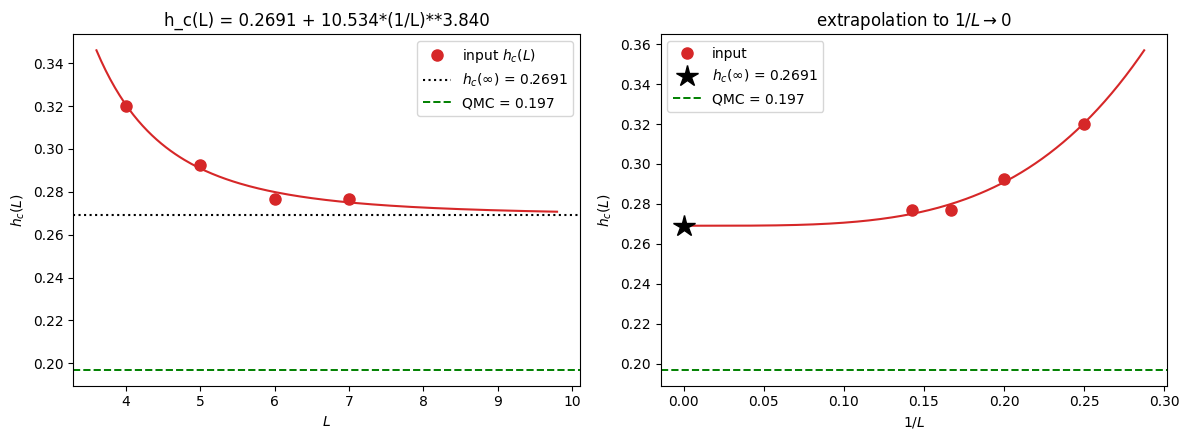

In [10]:
# ---- 7b · plot the manual fit (run 7a first) ----
mf = manual_fit
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
LL = np.linspace(mf["L"].min() * 0.9, mf["L"].max() * 1.4, 200)
ax[0].plot(mf["L"], mf["hc"], "o", ms=8, color="C3", label="input $h_c(L)$")
ax[0].plot(LL, hc_model(LL, mf["hc_inf"], mf["b"], mf["x"]), "-", color="C3")
ax[0].axhline(mf["hc_inf"], ls=":", color="k", label=rf"$h_c(\infty)$ = {mf['hc_inf']:.4f}")
ax[0].axhline(HZ_C_TRUE, ls="--", color="green", lw=1.4, label=f"QMC = {HZ_C_TRUE}")
ax[0].set(xlabel="$L$", ylabel="$h_c(L)$",
          title=f"h_c(L) = {mf['hc_inf']:.4f} + {mf['b']:.3f}*(1/L)**{mf['x']:.3f}")
ax[0].legend()
invL = 1.0 / mf["L"]; grid = np.linspace(0, invL.max() * 1.15, 200)
ax[1].plot(invL, mf["hc"], "o", ms=8, color="C3", label="input")
ax[1].plot(grid, mf["hc_inf"] + mf["b"] * grid ** mf["x"], "-", color="C3")
ax[1].plot(0, mf["hc_inf"], "*", ms=16, color="k", label=rf"$h_c(\infty)$ = {mf['hc_inf']:.4f}")
ax[1].axhline(HZ_C_TRUE, ls="--", color="green", lw=1.4, label=f"QMC = {HZ_C_TRUE}")
ax[1].set(xlabel="$1/L$", ylabel="$h_c(L)$", title=r"extrapolation to $1/L\to0$"); ax[1].legend()
plt.tight_layout(); plt.show()


In [ ]:
# ---- 7c · overlay a HAND-SPECIFIED curve: data + best fit + QMC + your (h_inf, b, x) ----
#      tweak MY_* and re-run to see which parameters reproduce the points AND hit the QMC line.
MY_HINF, MY_B, MY_X = 0.197, 0.52, 1.0     # <-- YOUR curve: h_c(L) = MY_HINF + MY_B*(1/L)**MY_X

mf = manual_fit
Lg = np.linspace(mf["L"].min() * 0.9, mf["L"].max() * 1.4, 200)
invL = 1.0 / mf["L"]; gg = np.linspace(0, invL.max() * 1.15, 200)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].plot(mf["L"], mf["hc"], "o", ms=9, color="C3", zorder=5, label="data $h_c(L)$")
ax[0].plot(Lg, hc_model(Lg, mf["hc_inf"], mf["b"], mf["x"]), "-", color="C3",
           label=rf"best fit ($h_\infty$={mf['hc_inf']:.4f})")
ax[0].plot(Lg, hc_model(Lg, MY_HINF, MY_B, MY_X), "-", color="C0",
           label=rf"mine ($h_\infty$={MY_HINF}, b={MY_B}, x={MY_X})")
ax[0].axhline(HZ_C_TRUE, ls="--", color="green", lw=1.4, label=f"QMC = {HZ_C_TRUE}")
ax[0].set(xlabel="$L$", ylabel="$h_c(L)$", title="vs $L$"); ax[0].legend(fontsize=8)
ax[1].plot(invL, mf["hc"], "o", ms=9, color="C3", zorder=5, label="data")
ax[1].plot(gg, mf["hc_inf"] + mf["b"] * gg ** mf["x"], "-", color="C3", label="best fit")
ax[1].plot(gg, MY_HINF + MY_B * gg ** MY_X, "-", color="C0", label="mine")
ax[1].plot(0, mf["hc_inf"], "*", ms=14, color="C3"); ax[1].plot(0, MY_HINF, "*", ms=14, color="C0")
ax[1].axhline(HZ_C_TRUE, ls="--", color="green", lw=1.4, label=f"QMC = {HZ_C_TRUE}")
ax[1].set(xlabel="$1/L$", ylabel="$h_c(L)$", title=r"extrapolation to $1/L\to0$"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

res = mf["hc"] - hc_model(mf["L"], MY_HINF, MY_B, MY_X)
print(f"my curve:  h_inf={MY_HINF}  b={MY_B}  x={MY_X}")
print(f"  intercept - QMC = {MY_HINF - HZ_C_TRUE:+.4f}")
print(f"  SSE vs data = {np.sum(res**2):.2e}   per-L resid: "
      + ", ".join(f"L{int(L)}={r:+.4f}" for L, r in zip(mf["L"], res)))
